# Discrete Hopfield networks


| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Dic 19, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Dic 20, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code and comments improvements |

A **Hopfield network** is a type of "recurrent" neural network, invented by John Hopfield in 1982, that acts as an **associative memory**. If you give it a partial or noisy version of a stored pattern, the system "flows" toward the nearest stable state—the original memory.

---

## 1. Some mathematical elements

### The weight matrix

The relationship between any two units $i$ and $j$ is stored in a weight matrix $\boldsymbol{W}\in\mathbb{R}^{N\times N}$, where $N$ is the number of neurons. This matrix represents the following characteristics of a Hopfield network:
1. **Symmetry:** The influence of unit $i$ on $j$  is the same as $j$ on $i$ ($w_{ij} = w_{ji}$).
2. **No self-feedback:** A unit doesn't influence itself ($w_{ii}=0$).

### The energy (Lyapunov) function

Just like a ball rolling into a valley, the network seeks to minimize its energy $E$. The energy of the state $\boldsymbol{s}$ is defined as:
$$
E(\boldsymbol{s}) = - \frac{1}{2}\sum_{i=1}^N\sum_{j=1}^N w_{ij} s_i s_j = -\frac{1}{2}\boldsymbol{s}^T\boldsymbol{W}\boldsymbol{s}
$$
where $v_i$ is the state of neuron $i$ (usually +1 or -1) and $w_{ij}$ is the weight (connection strength) between neuron $i$ and neuron $j$.


When the energy is at a local minimum, the system is stable. These minima in the energy landscape are our stored memories.

### Hebb's learning rule
How do we "teach" the network a pattern? We adjust the weights so that our desired pattern is a local minimum in the energy landscape. We use Hebbian learning, often summarized as "*Neurons that fire together, wire together.*"

To store $M$ patterns, the weight matrix $\boldsymbol{W}$ is calculated as:
$$
w_{ij} = \frac{1}{N} \sum_{\mu=1}^{M} \xi_i^{(\mu)} \xi_j^{(\mu)}
$$
where $\boldsymbol{\xi}^{(\mu)}$ is the $\mu$-th **fundamental memory**, i.e., the $\mu$-th pattern we want to store. This equation sets $w_{ii} = 0$ (no self-loops), so that a neuron does not connect to itself. We can rewrite this as, in terms of the outer product as:
$$
\boldsymbol{W} = \sum_{\mu=1}^{M} \boldsymbol{\xi}^{(\mu)} \left(\boldsymbol{\xi}^{(\mu)}\right)^T - M\boldsymbol{I}.
$$

### Storkey's learning rule
The Storkey learning rule (1997) modifies the Hebbian update by subtracting local-field interaction terms so that learning remains local and incremental.  Storkey also showed that a Hopfield network trained using this rule has a greater capacity than a corresponding network trained using the Hebbian rule.

For a single pattern $\boldsymbol{\xi}^{(\mu)}$ with components $\xi_i^{(\mu)} \in \{-1, +1\}$, the first‑order Storkey update for the weight $w_{ij}$ (with $i \neq j$) is:
$$
\Delta w_{ij}^{(\mu)} = \frac{\xi_i^{(\mu)} \xi_j^{(\mu)} - \xi_i^{(\mu)} h_{ji}^{(\mu)} - h_{ij}^{(\mu)} \xi_j^{(\mu)}}{N}
$$
where the local fields $h_i^{(\mu)}$ and $h_j^{(\mu)}$ are computed using the *current* weight matrix but excluding the $i\text{–}j$ connection itself:
$$
h_{ij}^{(\mu)} = \sum_{k=1, k\neq i,j}^N w_{ik}^{(\mu-1)} \xi_k^{(\mu)}, \qquad
h_{ji}^{(\mu)} = \sum_{k=1, k\neq i,j}^N w_{jk}^{(\mu-1)} \xi_k^{(\mu)}.
$$

Then the new weights are:
$$
w_{ij}^{(\mu)} \leftarrow w_{ij}^{(\mu-1)} + \Delta w_{ij}^{(\mu)}, \qquad
w_{ji}^{(\mu)} \leftarrow w_{ij}^{(\mu)}, \qquad
w_{ii}^{(\mu)} = 0.
$$

Here $\mu = 1, \ldots, M$ stands for the number of a pattern to memorize; $M$ is the total number of patterns to store.

 Storkey, Amos (1997). [*Increasing the capacity of a Hopfield network without sacrificing functionality*](https://homepages.inf.ed.ac.uk/amos/publications/Storkey1997IncreasingtheCapacityoftheHopfieldNetworkwithoutSacrificingFunctionality.pdf). Artificial Neural Networks – ICANN'97. Lecture Notes in Computer Science. Vol. 1327. Springer. pp. 451–6.

### The update rule
Once the weights are set, if we give the network a corrupted input (a distorted structure), we update the neurons iteratively to fix it. For a neuron $i$, we calculate its input (a.k.a. **activation** or **induced local field**) $h_i$:

$$
h_i = \sum_{j=1}^{N} w_{ij} s_j
$$

The new state $s_i'$ becomes:
$$
s_i' = \operatorname{sign}(h_i) =
\begin{cases}
+1 & \text{if } h_i \ge 0 \\
-1 & \text{if } h_i < 0
\end{cases}
$$

### Synchronous vs. Asynchronous:
* Synchronous: All neurons update at once (like a discrete time step simulation).
* Asynchronous: One neuron updates at a time (more biologically plausible and guaranteed to decrease Energy). We will use asynchronous updates to prevent oscillation.

---

## 2. Implementation from Scratch
Let's build this system using Python and NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Define my own sign function, which is different to np.sign()
def sign(x):
    return np.where(x >= 0, 1, -1)

class HopfieldNetwork:
    def __init__(self, N):
        """
        Initialize the network.
        N: Total number of neurons (e.g., 10x10 grid = 100 neurons)
        """
        self.N = N                 # size of the network, number of neurons
        self.W = np.zeros((N, N))  # weight matrix

    def energy(self, state_s):
        """Calculates the scalar energy of the current state s."""
        return -0.5 * state_s.T @ self.W @ state_s

    def store(self, patterns, algorithm='storkey'):
        """
        Store patterns (the fundamental memories)

        patterns: list of M  patterns or fundamental memories. Patterns are
                  arrays of +1 and -1.

        algorithm = 'hebb' or 'storkey'
            * 'hebb':    Hebb's learning rule.
            * 'storkey': Storkey's learning rule.
        """
        match algorithm:
            case 'hebb':
                for xi in patterns: # this iterates M times;
                    self.W += np.outer(xi, xi)

                # Normalize weights W by the size N of the network
                self.W /= self.N

            case 'storkey':
                for xi in patterns:
                    for i in range(self.N):
                        for j in range(i+1, self.N):  # i != j
                            # local fields excluding i and j
                            mask = np.ones(self.N, dtype=bool)
                            mask[[i, j]] = False

                            h_ij = self.W[i, mask] @ xi[mask]
                            h_ji = self.W[j, mask] @ xi[mask]

                            delta_w_ij = (xi[i]*xi[j] - xi[i]*h_ji - h_ij*xi[j])/self.N
                            self.W[i, j] += delta_w_ij
                            self.W[j, i]  = self.W[i, j] # enforce symmetry
            case _:
                raise ValueError("Invalid algorithm. Choose 'hebb' or 'storkey'.")

        # Set diagonal to zero (no self-connections)
        np.fill_diagonal(self.W, 0.0)

    def retrieve(self, probe, steps=200, mode='asynchronous'):
        """
        Iteratively update the state until it converges. This procedure moves
        the system toward a lower energy state.

        probe: it represents the initial state, an incomplete or noisy version
        of a fundamental memory of the network.

        mode:
        'asynchronous': Update one unit randomly and one at a time (always converges)
        'synchronous':  Update all units at once (it may fall in limit cycles)
        """
        state_s  = np.copy(probe)
        energy_history = [ self.energy(state_s) ]

        for _ in range(steps):
            match mode:
                case 'asynchronous':
                    # Pick random neurons to update one by one
                    i = np.random.randint(self.N)
                    # Compute the activation:
                    activation = self.W[i] @ state_s
                    # Update state based on sign
                    state_s[i] = sign(activation)
                case 'synchronous':
                    # Update all at once
                    activation = self.W @ state_s
                    # Update state based on sign
                    state_s = sign(activation)
                case _:
                    raise ValueError("Invalid mode. Choose 'asynchronous' or 'synchronous'.")

            energy_history.append(self.energy(state_s))

        return state_s, energy_history

---

## 3. Practical Example: Pattern Storage

Imagine we want to store two distinct patterns in an 8x8 grid.

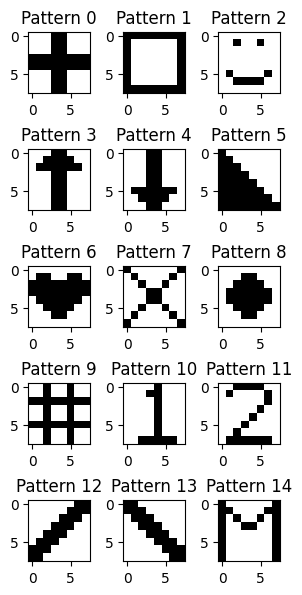

In [2]:
def plot_pattern(data, title, ax):
    """Helper to plot a binary grid (pattern)"""
    size = int(np.sqrt(len(data)))
    ax.imshow(data.reshape(size, size), cmap='binary')
    ax.set_title(title)
    #ax.axis('off')

# Create 15 8x8 patterns (flattened to 64 elements)
patterns = 15 * [None]

# Cross
p = np.full((8, 8), -1)
p[3:5, :] = 1
p[:, 3:5] = 1
patterns[0] = p.flatten()

# Border
p = np.full((8, 8), -1)
p[0, :] = 1; p[-1, :] = 1
p[:, 0] = 1; p[:, -1] = 1
patterns[1] = p.flatten()

# Smiley Face
p = np.full((8, 8), -1)
p[1, 2] = 1; p[1, 5] = 1     # Eyes
p[5, 1] = 1; p[5, 6] = 1     # Mouth corners
p[6, 2:6] = 1                # Smile bottom
patterns[2] = p.flatten()

# Arrow Up
p = np.full((8, 8), -1)
p[0, 3:5] = 1                # Tip
p[1, 2:6] = 1
p[2, 1:7] = 1
p[3:, 3:5] = 1               # Shaft
patterns[3] = p.flatten()

# Arrow Down
p = np.full((8, 8), -1)
p[:-3, 3:5] = 1              # Shaft
p[-3, 1:7] = 1
p[-2, 2:6] = 1
p[-1, 3:5] = 1               # Tip
patterns[4] = p.flatten()

# Triangle (Bottom-Left Fill)
p = np.full((8, 8), -1)
for r in range(8):
    for c in range(8):
        if r >= c: p[r, c] = 1
patterns[5] = p.flatten()

# Heart Shape
p = np.full((8, 8), -1)
p[1, 1:3] = 1; p[1, 5:7] = 1 # Top humps
p[2, 0:4] = 1; p[2, 4:8] = 1 # Widest part
p[3, 0:8] = 1
p[4, 1:7] = 1
p[5, 2:6] = 1
p[6, 3:5] = 1
patterns[6] = p.flatten()

#  Multiply Sign (x)
p = np.full((8, 8), -1)
np.fill_diagonal(p, 1)
np.fill_diagonal(np.fliplr(p), 1)
patterns[7] = p.flatten()

# Diamond (Filled)
p = np.full((8, 8), -1)
for r in range(8):
    for c in range(8):
        # Manhattan distance from center (3.5, 3.5)
        if abs(r - 3.5) + abs(c - 3.5) < 4.0:
            p[r, c] = 1
patterns[8] = p.flatten()

# Grid / Hash (#)
p = np.full((8, 8), -1)
p[2, :] = 1; p[5, :] = 1
p[:, 2] = 1; p[:, 5] = 1
patterns[9] = p.flatten()

# Number 1
p = np.full((8, 8), -1)
p[:, 4] = 1          # Stem
p[1, 3] = 1          # Serif top
p[7, 2:7] = 1        # Base
patterns[10] = p.flatten()

# Number 2
p = np.full((8, 8), -1)
p[0, 2:6] = 1        # Top arc
p[1, 1] = 1; p[1, 6] = 1
p[2, 6] = 1
p[3, 5] = 1; p[4, 4] = 1; p[5, 3] = 1; p[6, 2] = 1 # Diagonal
p[7, 1:7] = 1        # Base
patterns[11] = p.flatten()

# Forward Slash (Diagonal)
p = np.full((8, 8), -1)
np.fill_diagonal(np.fliplr(p), 1)
# Make it thicker
rng = np.arange(7)
p[rng, 6-rng] = 1; p[rng+1, 7-rng] = 1
patterns[12] = p.flatten()

# Back Slash (Diagonal)
p = np.full((8, 8), -1)
np.fill_diagonal(p, 1)
# Make it thicker
rng = np.arange(7)
p[rng, rng+1] = 1; p[rng+1, rng] = 1
patterns[13] = p.flatten()

# Letter M
p = np.full((8, 8), -1)
p[:, 0] = 1; p[:, 7] = 1   # Sides
p[1, 1] = 1; p[2, 2] = 1   # Left diag
p[3, 3] = 1; p[3, 4] = 1   # Middle
p[2, 5] = 1; p[1, 6] = 1   # Right diag
patterns[14] = p.flatten()

# Visualize the patterns
fig, ax = plt.subplots(5, 3, figsize=(3, 6))
for i in range(5*3):
    plot_pattern(patterns[i], f"Pattern {i}", ax.flatten()[i])
plt.tight_layout()
plt.show()

Now, store the patterns in the network:

In [3]:
# Initialize and store 4 patterns
net = HopfieldNetwork(8*8)

# WARNING!!!
# In this example, using Hebb's learning rule, increasing the number of patterns
# to 5, does store spurious memories. This does not respect the N/(2*log(N)) limit
# net.store(patterns[:4], algorithm='hebb')

# Storkeys's learning rule
net.store(patterns[:9], algorithm='storkey')

---

## 4. Retrieving memories

An important property of a content-addressable memory, like the one of the Hopfield network,  is the ability to retrieve a stored pattern, given a reasonable subset of the information content of that pattern. Moreover, a content-addressable memory is *error correcting* in the sense that
it can override inconsistent information in the cues presented to it.

Now, we will:

1. Train the network on the the 8x8 patterns
2. Take the "Cross," damage it significantly (noise).
3. Ask the network to "repair" it.

Let's see if it the network can repair the noisy pattern.

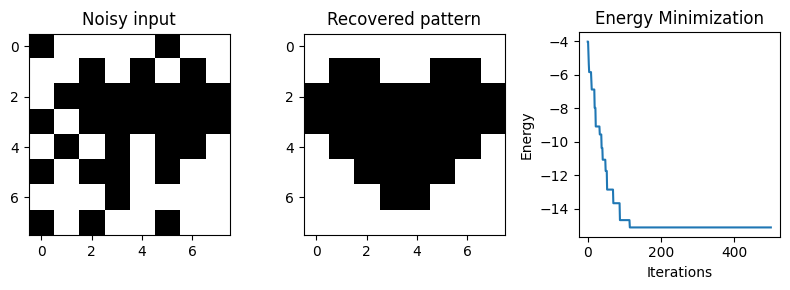

In [4]:
def test_one_pattern(p1, title1, p2, title2, energy=[]):
    if energy == []:
        fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    else:
        fig, ax = plt.subplots(1, 3, figsize=(8, 3))

    plot_pattern(p1, title1, ax[0])
    plot_pattern(p2, title2, ax[1])

    if energy != []:
        ax[2].plot(energy)
        ax[2].set_title("Energy Minimization")
        ax[2].set_xlabel("Iterations")
        ax[2].set_ylabel("Energy")

    plt.tight_layout()
    plt.show()

# Create noisy version of a pattern
noisy_pattern  = np.copy(patterns[6])
random_indices = np.random.choice(8*8, 15, replace=False)
noisy_pattern[random_indices] *= -1 # Flip 15 bits

# Run the network
recovered_pattern, energy = net.retrieve(noisy_pattern, steps=500, mode='asynchronous')

# Plot Results
test_one_pattern(noisy_pattern,     "Noisy input",
                 recovered_pattern, "Recovered pattern",
                 energy)

Notice that if the network stores a pattern , it also mathematically stores the inverted pattern.

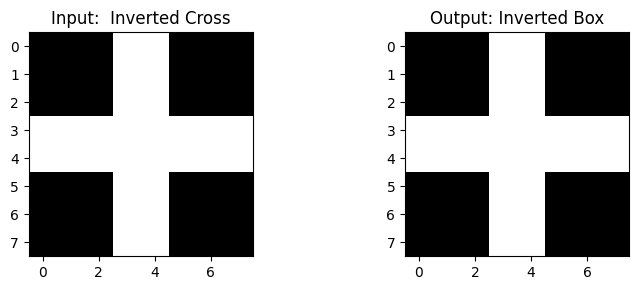

In [5]:
# Create an inverted version of the cross
inv_pattern = -patterns[0]

# Run prediction starting from the inverted pattern
recovered_inv, _ = net.retrieve(inv_pattern, steps=500, mode='asynchronous')
test_one_pattern(inv_pattern,   "Input:  Inverted Cross",
                 recovered_inv, "Output: Inverted Box")

---

## 5. Capacity Limitations

A Hopfield network can only store a number of patterns before they interfere with each other. The number of patterns that the network is able to measure is given by the, so called, **capacity** which is a measure of how many patterns can be stored in a network of a given size.

 Given a Hopfield network with $N$ units:
* When using Hebb's learning rule, its capacity is $C \cong \frac{N}{2 \log N}$.
* When using Storkey's learning rule, its capacity is $C \cong \frac{N}{\sqrt{2 \log N}}$.

These numbers are not absolute upper bounds but approximate values.

For example, for $N = 64$,
* Hebb's learning rule predicts $C = \frac{N}{2 \log N} = 7.7$
* Storkey's learning rule predicts $C = \frac{N}{\sqrt{2 \log N}} = 22.2$

<figure>
  <img src="capacities.png" alt="Source: Storkey (1997)."  title="Source: Storkey (1997)."  width="600"/>
  <figcaption align="left">Source: Storkey (1997).</figcaption>
</figure>

When we exceed the storage capacity, the energy landscape becomes "choppy." Instead of having deep, clear valleys for each memory, the valleys merge or create **spurious attractors**, that is, stable states that are combinations of your memories but represent nothing useful (memories get "muddled."). They often look like a mix of two stored patterns or the exact inverse of a stored pattern (since the energy formula is symmetric).

We will try to store all **15 patterns** in our 64-unit network. Since the theoretical limit, for the Hebbian learning rule is approximately 7.7, the network should "break":

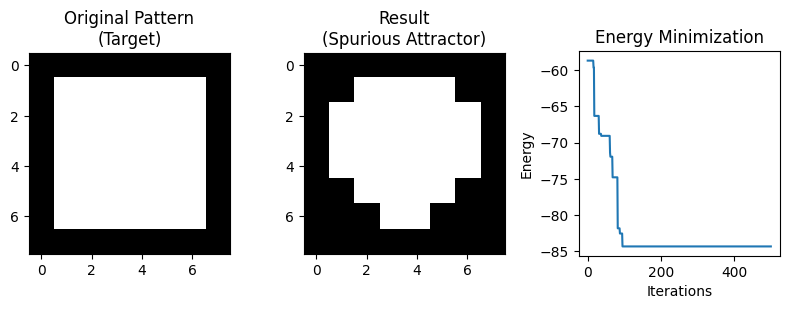

Retrieval Accuracy: 87.50%


In [6]:
# Train the network on all 12 patterns
overloaded_net = HopfieldNetwork(8*8)
overloaded_net.store(patterns, algorithm='hebb')

# Try to retrieve the a pattern we stored
original_pattern = patterns[1]
# Add just a tiny bit of noise (flip 2 bits)
noisy_test = np.copy(original_pattern)
noisy_test[np.random.choice(64, 2)] *= -1

recovered_pattern, energy = overloaded_net.retrieve(noisy_test, steps=500)

# Compare original vs recovered
test_one_pattern(original_pattern,  "Original Pattern\n(Target)",
                 recovered_pattern, "Result\n(Spurious Attractor)",
                 energy)

# Calculate accuracy
accuracy = np.mean(recovered_pattern == original_pattern)
print(f"Retrieval Accuracy: {accuracy * 100:.2f}%")

### What is happening here?

* **Spurious States (Ghost Attractors):** Sometimes, the mathematics creates energy valleys that we didn't intend to store.
* **Mixtures:** Sometimes the network settles into a state that is a mix of several patterns.
* **Overloading:** Because the weight matrix $\boldsymbol{W}$ is a fixed size (64x64), adding too many patterns causes the "signals" from different memories to interfere with each other (crosstalk).